In [21]:
# from google.colab import drive
# drive.mount('/content/drive')
# raiz="drive/MyDrive/proyecto_mineria/"
raiz=""

# Cargar datos y generar los conjuntos de entrenamiento y test

In [22]:
import pandas as pd
nombre_csv_logs="presentacion1_resultados.csv"
# file_path = 'data_set_limpio.pkl'
file_path = f'{raiz}datasets_pkl/data_set_limpio_sin_not_for_sale.pkl'

df = pd.read_pickle(file_path)

# Display the loaded DataFrame
print("shape: ",df.shape)
print(df.columns)
df.sample(n=5)


shape:  (186795, 70)
Index(['Nat', 'Division', 'Club', 'Based', 'Preferred Foot', 'Right Foot',
       'Left Foot', 'Position', 'Height', 'Weight', 'Age', 'Wage', 'AT Apps',
       'AT Gls', 'Team', 'Caps', 'Yth Apps', 'Style', 'Rc Injury', 'Best Role',
       'Best Duty', 'Best Pos', 'Acc', 'Aer', 'Agg', 'Agi', 'Ant', 'Bal',
       'Bra', 'Cmd', 'Com', 'Cmp', 'Cnt', 'Cor', 'Cro', 'Dec', 'Det', 'Dri',
       'Ecc', 'Fin', 'Fir', 'Fla', 'Fre', 'Han', 'Hea', 'Jum', 'Kic', 'Ldr',
       'Lon', 'L Th', 'Mar', 'Nat .1', 'OtB', '1v1', 'Pac', 'Pas', 'Pen',
       'Pos', 'Pun', 'Ref', 'TRO', 'Sta', 'Str', 'Tck', 'Tea', 'Tec', 'Thr',
       'Vis', 'Wor', 'transfer_value_estimado'],
      dtype='object')


,Nat,Division,Club,Based,Preferred Foot,Right Foot,Left Foot,Position,Height,Weight,Age,Wage,AT Apps,AT Gls,Team,Caps,Yth Apps,Style,Rc Injury,Best Role,Best Duty,Best Pos,Acc,Aer,Agg,Agi,Ant,Bal,Bra,Cmd,Com,Cmp,Cnt,Cor,Cro,Dec,Det,Dri,Ecc,Fin,Fir,Fla,Fre,Han,Hea,Jum,Kic,Ldr,Lon,L Th,Mar,Nat .1,OtB,1v1,Pac,Pas,Pen,Pos,Pun,Ref,TRO,Sta,Str,Tck,Tea,Tec,Thr,Vis,Wor,transfer_value_estimado
94308,ITA,Italian Serie D Grp. I,Catania,Italy (Serie D Grp. I),Right Only,Very Strong,Weak,M (C),178,65,17,1100,2,0,-,0,0,Physical,-,Mezzala,Support,M (C),11,1,12,13,8,6,4,3,3,6,5,4,2,13,2,4,3,6,7,8,5,1,5,6,3,11,5,1,8,16,5,4,13,13,4,4,2,2,3,5,4,7,7,12,3,11,9,40000
6508,COL,Colombian Second Division,Llaneros F.C.,Colombia (Second Division),Left,Weak,Very Strong,D (C),179,80,25,9750,55,1,-,0,3,Leader,-,No-Nonsense Centre-Back,Stopper,D (C),10,2,18,10,13,12,16,3,1,8,10,7,7,10,12,6,2,8,9,6,6,3,13,11,1,9,6,7,12,10,6,2,10,9,3,13,2,1,1,13,14,13,12,8,2,9,14,30000
153939,SCO,Sky Bet Championship,Hull,England (Sky Bet Championship),Right,Very Strong,Fairly Strong,"AM (RL), ST (C)",189,87,21,32500,78,10,U21,0,3,Technical,-,Inverted Winger,Support,AM (L),12,2,9,11,9,10,12,3,3,10,9,10,10,9,13,12,2,11,12,13,10,2,10,12,2,9,9,10,4,14,10,3,12,11,13,6,1,3,2,10,11,8,12,12,3,10,11,2450000
30010,BRA,Brazilian National Lower Division,Uberlândia,Brazil (Lower Division),Right Only,Very Strong,Weak,"AM (RL), ST (C)",183,74,26,400,6,2,-,0,0,Intelligent,-,Poacher,Attack,ST (C),13,3,5,11,12,7,8,2,1,11,7,6,9,12,11,12,1,13,11,11,6,3,10,5,1,12,7,5,5,13,9,1,13,6,6,6,3,2,2,9,6,6,6,11,3,5,8,0
147973,NZL,New Zealand Northern League,Western Springs,New Zealand (Northern League),Left,Weak,Very Strong,D/WB/M/AM (L),172,77,21,0,12,0,-,0,0,Technical,-,Winger,Support,M (L),12,2,10,9,8,8,7,1,2,8,8,4,7,8,9,8,3,3,11,6,5,1,5,2,2,11,7,6,2,7,10,1,13,11,1,6,3,2,2,7,4,8,3,7,3,5,8,0


# Generar conjuntos de entrenamiento y test

In [23]:
import pandas as pd
import json
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error

def log_results(model, method_name, X_train, y_train, X_test, y_test,
                filepath=f"{raiz}{nombre_csv_logs}.csv"):
    params_dict = model.get_params()
    for k, v in params_dict.items():
        try:
            json.dumps(v)
        except TypeError:
            params_dict[k] = str(v)
    params = json.dumps(params_dict)

    y_pred = model.predict(X_test)

    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test,  y_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    row = {
        "method":          method_name,
        "hyperparameters": json.dumps(params),
        "r2_train":        r2_train,
        "r2_test":         r2_test,
        "mae":             mae,
        "rmse":            rmse
    }

    residuals = y_test - y_pred
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(residuals, bins=50, kde=True, color="blue")
    plt.axvline(x=0, color='red', linestyle='--')
    plt.title("Residuals Distribution")
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)],
             color='red', linestyle='--')
    plt.title("Regression Fit: Actual vs Predicted")
    plt.xlabel("Actual Transfer Values")
    plt.ylabel("Predicted Transfer Values")

    plt.suptitle(method_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"  R² train : {r2_train:.4f}")
    print(f"  R² test  : {r2_test:.4f}")
    print(f"  MAE      : {mae:.2f}")
    print(f"  RMSE     : {rmse:.2f}")

    try:
        df_log = pd.read_csv(filepath)
        df_log = pd.concat([df_log, pd.DataFrame([row])], ignore_index=True)
    except FileNotFoundError:
        df_log = pd.DataFrame([row])

    df_log.to_csv(filepath, index=False)

# Generar conjuntos de entrenamiento y test

In [24]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [25]:
import clustering as cl

kmeans_model_club = cl.fit_kmeans(train_df, columna="Club")
kmeans_model_nat = cl.fit_kmeans(train_df, columna="Nat")
kmeans_model_division = cl.fit_kmeans(train_df, columna="Division")


train_df = cl.apply_kmeans(train_df, kmeans_model_club)
train_df = cl.apply_kmeans(train_df, kmeans_model_nat)
train_df = cl.apply_kmeans(train_df, kmeans_model_division)

test_df = cl.apply_kmeans(test_df, kmeans_model_club)
test_df = cl.apply_kmeans(test_df, kmeans_model_nat)
test_df = cl.apply_kmeans(test_df, kmeans_model_division)



# Considerar solo las más importantes
Si previamente ejecutamos el algoritmo y ya tenemos el archivo

In [26]:
import json
target="transfer_value_estimado"
with open("importantes.json", "r") as f:
    cols_to_keep = json.load(f)
    
cols_to_keep.append(target)
train_df=train_df[cols_to_keep]
test_df=test_df[cols_to_keep]

In [27]:
target="transfer_value_estimado"
drop_columns=["Club","Nat","Division",target]
X_train = train_df.drop(columns=drop_columns)
y_train = train_df[target]

X_test = test_df.drop(columns=drop_columns)
y_test = test_df[target]

In [28]:
X_train.columns

Index(['Wage', 'Age', 'Based', 'Acc', 'Caps', 'Pac', 'Club_cluster', 'Cmp',
       'Dec', 'Str', 'Team', 'Bal', 'Dri', 'AT Gls', 'Tec', 'Tea', 'Mar',
       'Position', 'Height', 'AT Apps', 'Pen', 'Right Foot', 'L Th', 'Wor',
       'Han', 'Ant', 'Cor', 'Vis', 'Com', 'Preferred Foot', 'Yth Apps', 'Cro',
       'Fir', 'Best Pos', 'Ref', 'Jum', 'Aer', 'Pos', 'Nat_cluster',
       'Division_cluster'],
      dtype='object')

## One Hot para las features categóricas

In [29]:
# import numpy as np
# # categorical_cols=["Nat_cluster","Division_cluster","Club_cluster","Preferred Foot","Right Foot","Left Foot","Best Pos","Best Duty","Style","Best Role","Rc Injury"]
# categorical_cols=["Nat_cluster","Division_cluster","Best Duty","Style"]
# X_train = pd.get_dummies(X_train, columns=categorical_cols)
# X_test  = pd.get_dummies(X_test, columns=categorical_cols)

# X_train, X_test = X_train.align(X_test, join='left', axis=1,fill_value=0)

In [30]:
# X_train = X_train.select_dtypes(include=[np.number,np.bool_])
# X_test = X_test.select_dtypes(include=[np.number,np.bool_])

In [31]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = pd.DataFrame(
#     scaler.fit_transform(X_train),
#     columns=X_train.columns,
#     index=X_train.index
# )

# X_test = pd.DataFrame(
#     scaler.transform(X_test),
#     columns=X_test.columns,
#     index=X_test.index
# )

In [32]:
print(X_train.shape)
print(X_test.shape)

(149436, 40)
(37359, 40)


# Entrenamiento

In [33]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import HistGradientBoostingRegressor

# 1. Identify categorical columns
cat_cols = X_train.select_dtypes(exclude=['number']).columns.tolist()

print(f"Categorical columns: {cat_cols}")

# 2. Copy datasets
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

# 3. Encode all categorical columns
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_encoded[cat_cols] = encoder.fit_transform(
    X_train[cat_cols]
)

X_test_encoded[cat_cols] = encoder.transform(
    X_test[cat_cols]
)

# 4. Train model
model = HistGradientBoostingRegressor()

# 

Categorical columns: ['Based', 'Team', 'Position', 'Right Foot', 'Preferred Foot', 'Best Pos']


# Entrenamiento y Evaluación

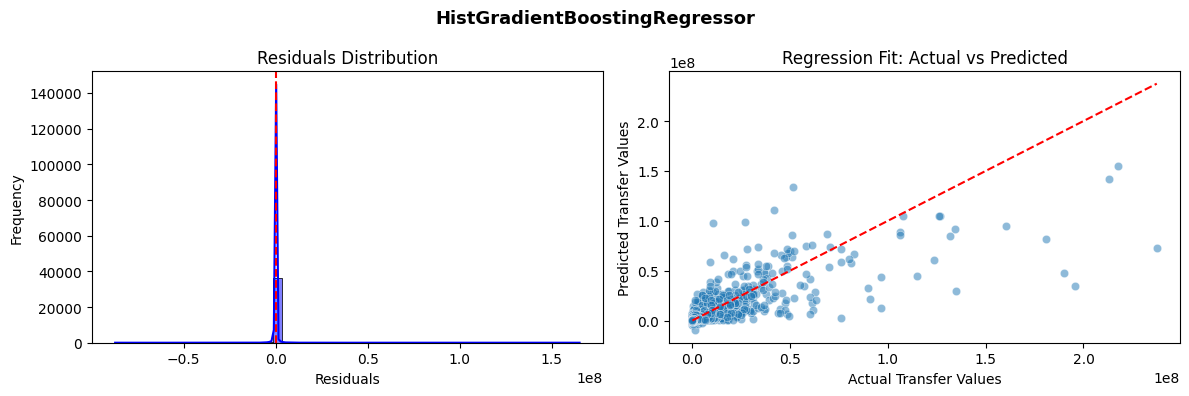

  R² train : 0.8574
  R² test  : 0.6442
  MAE      : 341052.02
  RMSE     : 2671081.46


In [34]:
model.fit(X_train_encoded, y_train)
# model.fit(X_train_encoded, y_train)

# # 5. Predict
preds = model.predict(X_test_encoded)
log_results(model,"HistGradientBoostingRegressor",X_train_encoded,y_train,X_test_encoded,y_test,filepath=nombre_csv_logs)

In [35]:
preds = model.predict(X_test_encoded)
print("saco ",model.score(X_test_encoded,y_test))
preds

saco  0.6441662589772457


array([324364.58981311, -20578.9207744 ,  33297.88820023, ...,
        37971.90967439,  19562.42348754,  56210.41561781], shape=(37359,))

# Feature importance

In [36]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    model,          # trained HistGradientBoostingRegressor
    X_test_encoded,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "feature": X_test_encoded.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

print(importance_df)

             feature  importance_mean  importance_std
0               Wage    381625.489039     3963.129952
1                Age    230011.166696     8230.885748
2              Based     16247.800870     1855.230694
4               Caps      6087.769576      339.987110
6       Club_cluster      5994.168797      169.234956
8                Dec      5896.358681     1630.122670
12               Dri      5461.510218      624.373420
5                Pac      4743.673560     1259.098817
3                Acc      4184.423464      772.964619
25               Ant      4155.507641      866.878231
14               Tec      3041.616424      670.387623
7                Cmp      2529.041447      972.176564
11               Bal      2504.096333      539.037082
19           AT Apps      2381.766375      925.446019
32               Fir      1938.697364      162.257920
34               Ref      1740.408744      381.340311
10              Team      1622.399662      627.243875
37               Pos      12

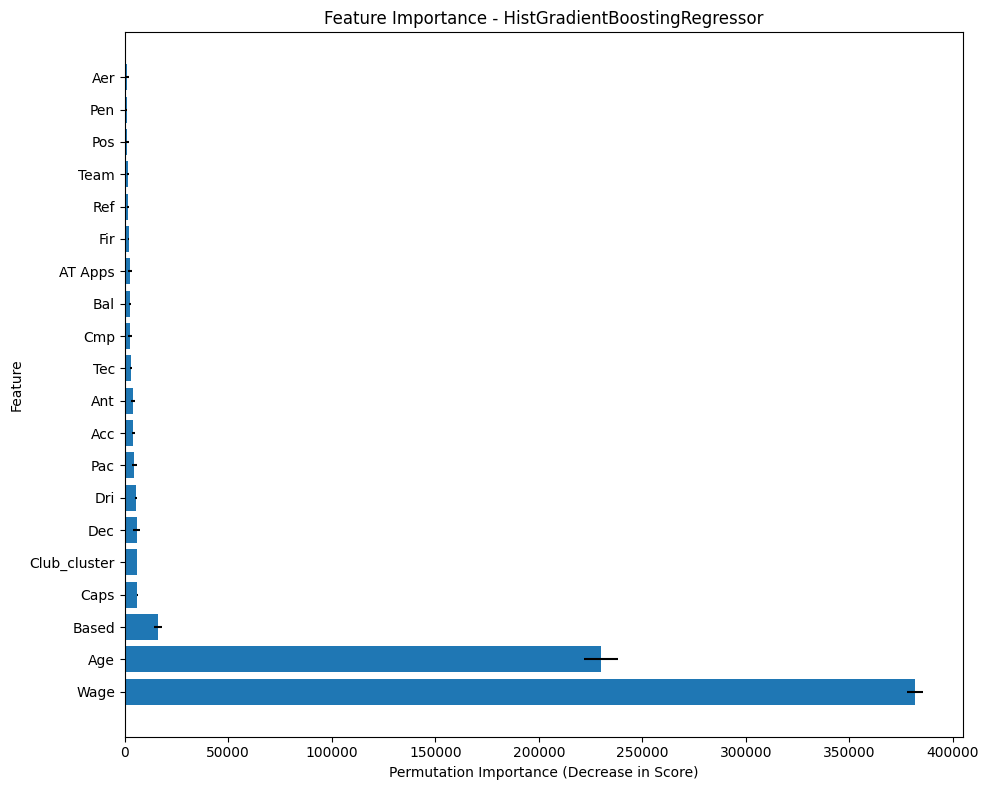

In [37]:
import matplotlib.pyplot as plt

# Optional: keep only top N features
top_n = 20
plot_df = importance_df.head(top_n)

# Create figure
plt.figure(figsize=(10, 8))

# Horizontal bar plot
plt.barh(
    plot_df["feature"],
    plot_df["importance_mean"],
    xerr=plot_df["importance_std"]
)

# Labels and title
plt.xlabel("Permutation Importance (Decrease in Score)")
plt.ylabel("Feature")
plt.title("Feature Importance - HistGradientBoostingRegressor")

# Highest importance at top
# plt.gca().invert_yaxis()

# Better spacing
plt.tight_layout()

# Show plot
plt.show()

In [38]:
import pandas as pd
visualizar_todo=True
if visualizar_todo:
    # Show all rows
    pd.set_option('display.max_rows', None)

    # Show all columns
    pd.set_option('display.max_columns', None)

    # Show full content of each cell (prevent text truncation)
    pd.set_option('display.max_colwidth', None)

print(importance_df)

             feature  importance_mean  importance_std
0               Wage    381625.489039     3963.129952
1                Age    230011.166696     8230.885748
2              Based     16247.800870     1855.230694
4               Caps      6087.769576      339.987110
6       Club_cluster      5994.168797      169.234956
8                Dec      5896.358681     1630.122670
12               Dri      5461.510218      624.373420
5                Pac      4743.673560     1259.098817
3                Acc      4184.423464      772.964619
25               Ant      4155.507641      866.878231
14               Tec      3041.616424      670.387623
7                Cmp      2529.041447      972.176564
11               Bal      2504.096333      539.037082
19           AT Apps      2381.766375      925.446019
32               Fir      1938.697364      162.257920
34               Ref      1740.408744      381.340311
10              Team      1622.399662      627.243875
37               Pos      12

In [39]:
genera_json=False
if genera_json:
    importantes=importance_df.loc[importance_df["importance_mean"] >= 0, "feature"].unique()
    importantes=importantes.tolist()
    import json

    with open("importantes.json", "w") as f:
        json.dump(importantes, f)


# Evaluar modelo con gente "barata"

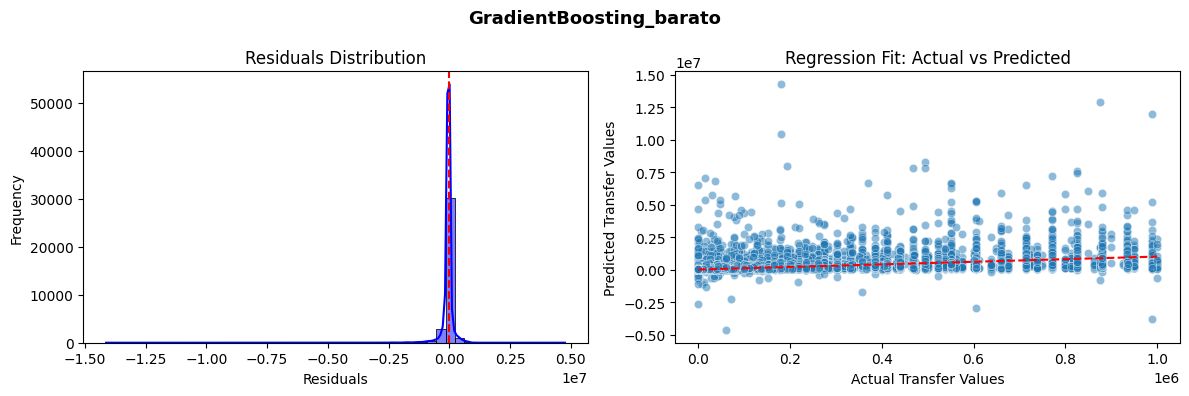

  R² train : 0.8574
  R² test  : -2.8942
  MAE      : 115635.89
  RMSE     : 347551.43


In [40]:
mask = y_test <= 1e6

X_test_barato = X_test_encoded[mask]
y_test_barato = y_test[mask]
log_results(model,"GradientBoosting_barato",X_train_encoded,y_train,X_test_barato,y_test_barato,filepath=nombre_csv_logs)